#**Rainall Forecasting**

## Importing Libraries


In [24]:
import pandas as pd # for importing the dataset and EDA
import numpy as np # for mathematical operations
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # for generating heatmap

## Importing the dataset

In [25]:
df = pd.read_csv('/content/drive/MyDrive/NBICT LAB PDSML-B-8/9. Forecasting Rainfall/weather.csv')

## Data Cleaning & Preposseing

*If a column doesn’t have 35% of the data → drop it → otherwise model becomes garbage*

### Missing data visualization

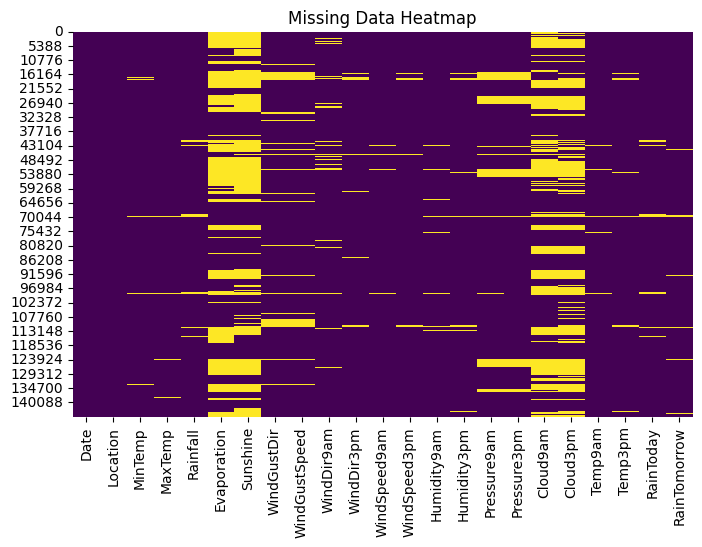

In [26]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

### Droping columns with > 35% Missing data

In [27]:
df = df.drop(columns=["Evaporation", "Sunshine", "Cloud9am", "Cloud3pm"])

### Droping the row where target is missing

In [28]:
df = df.dropna(subset=["RainTomorrow"])

### Filling the missing numeric value with the median of that column

In [29]:
# Selecting the Numeric column
numeric_cols = df.select_dtypes(include=["float64"]).columns
# Filling value
medians = df[numeric_cols].median()
df[numeric_cols] = df[numeric_cols].fillna(medians)

### Filling categorical gaps with the mode

In [30]:
cat_cols = df.select_dtypes(include=["object"]).columns
for cols in cat_cols:
  df[cols] = df[cols].fillna(df[cols].mode()[0])

## Encoding the Categorical Data

### Extracting Month from the Date

In [31]:
# Converting the "Date" column to datetime objects
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
# Making a new column
df["Months"] = df['Date'].dt.month
# Droping the original "Date" column as it's no longer needed for the model
df = df.drop(columns=["Date"])

In [32]:
# converting "Yes" to 1 and "No" to 0
df["RainToday"] = df["RainToday"].map({"Yes": 1, "No": 0})

In [33]:
# Encoding the "RainTomorrow" column
df["RainTomorrow"] = df["RainTomorrow"].map({"Yes": 1, "No": 0})

## Spliting the dataset into training set and test set

In [34]:
# Create the features (X) by dropping the target column
X = df.drop('RainTomorrow', axis=1)

# Create the target (y) by selecting only that column
y = df['RainTomorrow']

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= 43)

### One-Hot Encoding

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [37]:
# Identify the categorical columns that need encoding
cat_cols = X.select_dtypes(exclude = np.number).columns.tolist()
# Identify the numeric columns
num_cols = X.select_dtypes(include = np.number).columns.tolist()

In [38]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

pre = ColumnTransformer([
    ("cat", categorical_transformer, cat_cols),
    ("num", numeric_transformer, num_cols)
])

In [39]:
pre.fit_transform(X_train)

array([[ 0.        ,  0.        ,  0.        , ..., -2.80450812,
        -0.53358898, -0.11818678],
       [ 0.        ,  0.        ,  0.        , ..., -0.22922727,
        -0.53358898, -0.41009703],
       [ 0.        ,  0.        ,  0.        , ..., -0.79666203,
        -0.53358898,  0.75754399],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -0.72391399,
         1.87410166, -0.41009703],
       [ 0.        ,  0.        ,  0.        , ..., -0.21467766,
        -0.53358898,  0.75754399],
       [ 0.        ,  0.        ,  0.        , ...,  1.13843601,
        -0.53358898,  1.04945424]])

In [40]:
# Getting names of encoded categorical columns
cat_iv_names = pre.named_transformers_["cat"].get_feature_names_out(cat_cols)

# Combining the categorical columns with the numeric columns
all_iv_names = list(cat_iv_names) + num_cols

In [41]:
# Converting the transformed output to a DataFrame
X_trasformed = pre.fit_transform(X)

tr_df = pd.DataFrame(X_trasformed, columns = all_iv_names)

## Training the model

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [45]:
pipe_lr = Pipeline([
    ("preprocessing", pre),
    ("classification", LogisticRegression(max_iter=1000, class_weight='balanced')) # class_weight = "balanced" -> automatically increases the importance of the minority class.
])

In [46]:
# 2. Training: The model looks at X_train_scaled and learns the patterns in y_train
pipe_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Location', 'WindGustDir',
                                                   'WindDir9am',
                                                   'WindDir3pm']),
                                                 ('num', StandardScaler(),
                                                  ['MinTemp', 'MaxTemp',
                                                   'Rainfall', 'WindGustSpeed',
                                                   'WindSpeed9am',
                                                   'WindSpeed3pm',
                                                   'Humidity9am', 'Humidity3pm',
                                                   'Pressure9am', 'Pressure3pm',
                                                   'Temp9am', 'Temp3pm',
                                                   'RainToday', 'Months'])])),
                ('classification',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

## Predicting the test set result

In [47]:
# 3. Prediction: We ask the model to guess the results for our hidden test data
y_pred = pipe_lr.predict(X_test)

## Model evaluation

In [48]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Print the flat accuracy score

In [49]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.2%}")

Overall Accuracy: 79.05%


### Print the confusion matrix raw numbers

In [50]:
print("Confusion Matrix Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix Matrix:
[[17614  4450]
 [ 1507  4868]]


### Print the comprehensive classification report

This automatically calculates Precision, Recall, and F1-Score for BOTH classes (0 and 1)


In [51]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Rain (0)', 'Rain (1)']))

Classification Report:
              precision    recall  f1-score   support

 No Rain (0)       0.92      0.80      0.86     22064
    Rain (1)       0.52      0.76      0.62      6375

    accuracy                           0.79     28439
   macro avg       0.72      0.78      0.74     28439
weighted avg       0.83      0.79      0.80     28439



# Building the ROC Curve

In [52]:
from sklearn.metrics import roc_curve, auc

In [53]:
# probability prediction
y_prob = pipe_lr.predict_proba(X_test)[:,1]

In [54]:
print(y_prob[:20])

[0.85883123 0.90557879 0.16408027 0.20611339 0.74099703 0.18152795
 0.22438429 0.05228729 0.68115277 0.12418117 0.31738584 0.88653023
 0.58892226 0.36705248 0.85652259 0.64028142 0.44157497 0.11136481
 0.26962055 0.78626179]


## Calculating the False Positive Rate and True Positive Rate

In [55]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [56]:
auc = auc(fpr, tpr)
print("AUC:", auc)

AUC: 0.8610186231853149


## Ploting the ROC curve

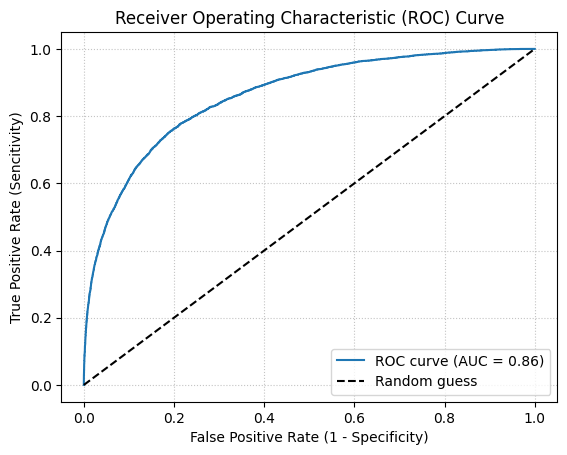

In [57]:
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sencitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True, linestyle=':', alpha = 0.75)
plt.show()

## Making a single prediction

In [58]:
# model = pipe_lr

# 1. Grab a single sample row form your features to use as a template
# This ensures all 107 columns with one-hot encoded coumns are present and in order
new_day_df = X.iloc[[0]].copy()

#2. Modify the fearures to represent your customs "new day"
# (Change whatever variables you want to test)
new_day_df['MinTemp'] = 15.2
new_day_df['MaxTemp'] = 26.5
new_day_df['Rainfall'] = 0.0
new_day_df['Humidity3pm'] = 65.0  # High humidity usually triggers rain
new_day_df['Pressure3pm'] = 1010.2


# 4. Predict the Probability (Recommended)
# returns a list like [[prob_of_no_rain, prob_of_rain]]
probabilities = pipe_lr.predict_proba(new_day_df)
rain_probability = probabilities[0][1] #first row second column

# 5. Predict the Hard Label (0 or 1)
hard_prediction = pipe_lr.predict(new_day_df)

# 6. Print the formatted results
print(f"Probability of Rain Tomorrow: {rain_probability:.2%}")

if hard_prediction == 1:
    print("Final Forecast: Rain Tomorrow (Bring an umbrella! 🌧️)")
else:
    print("Final Forecast: No Rain Tomorrow (Clear skies! ☀️)")


Probability of Rain Tomorrow: 64.48%
Final Forecast: Rain Tomorrow (Bring an umbrella! 🌧️)
